# Simple linear regression example in PyTorch

OK gang, lets do somet basic PyTorch programming for a trivial linear regression problem

Epoch [5/60], Loss: 5.8432
Epoch [10/60], Loss: 2.4700
Epoch [15/60], Loss: 1.1035
Epoch [20/60], Loss: 0.5499
Epoch [25/60], Loss: 0.3256
Epoch [30/60], Loss: 0.2347
Epoch [35/60], Loss: 0.1979
Epoch [40/60], Loss: 0.1830
Epoch [45/60], Loss: 0.1770
Epoch [50/60], Loss: 0.1745
Epoch [55/60], Loss: 0.1735
Epoch [60/60], Loss: 0.1731


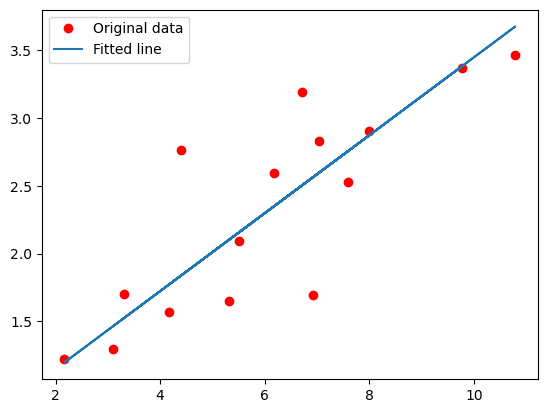

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Parameters
input_size = 1 # input dimensionality
output_size = 1 # output dimensionality, so if == 1 then y = (b1 * x1) + b0
num_epochs = 60 # how many iterations to run / train?
learning_rate = 0.001 # talk about in class!

# Toy dataset
x_train = np.array([[3.3], [4.4], [5.5], [6.71], [6.93], [4.168], 
                    [9.779], [6.182], [7.59], [2.167], [7.042], 
                    [10.791], [5.313], [7.997], [3.1]], dtype=np.float32)

y_train = np.array([[1.7], [2.76], [2.09], [3.19], [1.694], [1.573], 
                    [3.366], [2.596], [2.53], [1.221], [2.827], 
                    [3.465], [1.65], [2.904], [1.3]], dtype=np.float32)
# so, each of these make up a pair, e.g., (3.3, 1.7), (4.4, 2.76), ...

# Linear regression model (a simple neuron!)
# simple, its holds onto a weight vector with a bias term, so x * w
model = nn.Linear(input_size, output_size)

# Loss and optimizer
criterion = nn.MSELoss() # this is mean squared error -> ( out output - real value )^2
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) # says use stochastic gradient descent

# Train the model
for epoch in range(num_epochs): # train for num_epochs 
    
    # Convert numpy arrays to torch tensors
    inputs = torch.from_numpy(x_train) # this puts into torch for PyTorch
    targets = torch.from_numpy(y_train) # also, note, this is the full set of numbers above, an array!

    # Forward pass
    outputs = model(inputs) # what outputs given our current weights?
    loss = criterion(outputs, targets) # evaluate the loss
    
    # Backward error and optimize!
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # just some simple reporting
    if (epoch+1) % 5 == 0:
        print ('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))

# Plot the graph
predicted = model(torch.from_numpy(x_train)).detach().numpy()
plt.plot(x_train, y_train, 'ro', label='Original data')
plt.plot(x_train, predicted, label='Fitted line')
plt.legend()
plt.show()

# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')